In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [8]:
corr = df.corr(numeric_only=True)
print(corr["Churn"].sort_values(ascending=False))

Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn, dtype: float64


In [9]:
df.drop("customerID", axis=1, inplace=True)

In [10]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
print(df["TotalCharges"].dtype)

object


In [12]:
df["TotalCharges"]

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [96]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [14]:
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [15]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [97]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [17]:
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [18]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

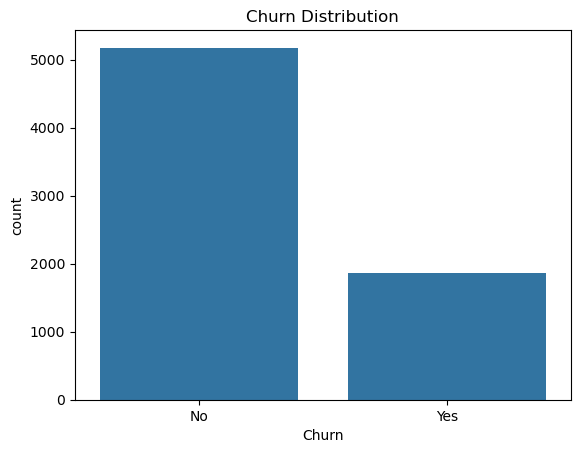

In [30]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

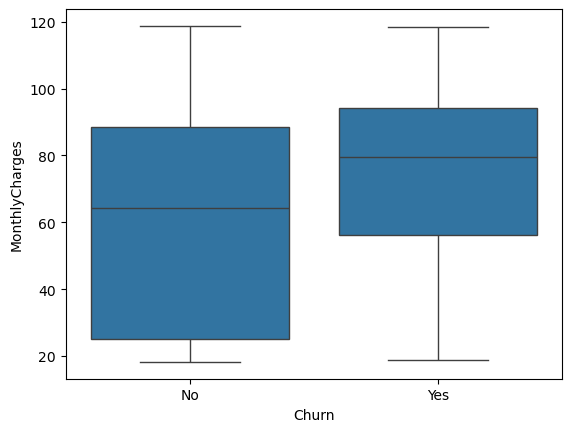

In [32]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

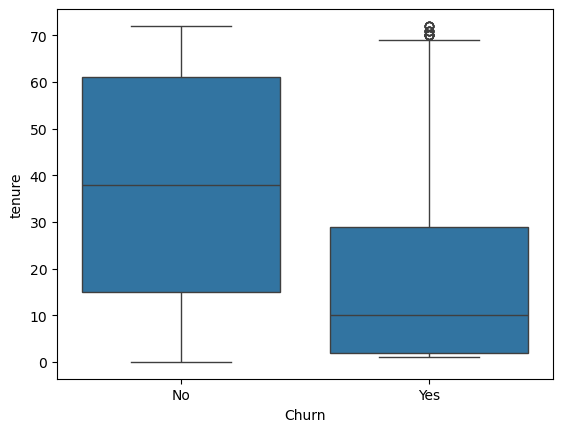

In [33]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [34]:
#Create RFM Features

In [35]:
#Lower tenure = more recent (more likely to churn)
df["Recency"] = df["tenure"]

In [36]:
#count how many services a user is using
# 1. Define the services (excluding InternetService if you don't want to count it as a 1/0)
services = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", 
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# 2. Convert to numeric, forcing errors to NaN and then filling with 0
for col in services:
    # Add .infer_objects(copy=False) at the end of the replace call
    df[col] = df[col].replace({"Yes": 1, "No": 0, "No internet service": 0, "No phone service": 0}).infer_objects(copy=False)
    
    # Your existing numeric conversion (keep this as a safety net)
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3. Now sum will work perfectly
df["Frequency"] = df[services].sum(axis=1)

In [37]:
#Monetary (M)
df["Monetary"] = df["TotalCharges"]

In [38]:
df[["Recency", "Frequency", "Monetary"]].head()

,Recency,Frequency,Monetary
0,1,1,29.85
1,34,3,1889.50
2,2,3,108.15
3,45,3,1840.75
4,2,1,151.65


In [39]:
df["Monetary"] = pd.to_numeric(df["Monetary"], errors='coerce')

df["Monetary"] = df["Monetary"].fillna(0)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[["Recency", "Frequency", "Monetary"]])

In [40]:
#RFM Segmentation using K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df["Segment"] = kmeans.fit_predict(rfm_scaled)

In [41]:
#Interpret Segments
df.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
0,52.619707,2.010586,1986.514495
1,61.363112,5.941210,5705.725821
2,8.893693,1.608885,371.585185
3,22.121232,4.395125,1799.643779


In [42]:
df_model = df.copy()

In [43]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [44]:
#This converts Yes/No → 0/1
X = pd.get_dummies(X, drop_first=True)

In [49]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000) 

# train Model (Logistic Regression) 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [52]:
#Predictions
y_pred = model.predict(X_test)

In [53]:
#Evaluate Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8168914123491838
[[935 101]
 [157 216]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [54]:
# Random Forest (Improved Model)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Random Forest:
               precision    recall  f1-score   support

           0       0.91      0.81      0.86      1036
           1       0.59      0.76      0.67       373

    accuracy                           0.80      1409
   macro avg       0.75      0.79      0.76      1409
weighted avg       0.82      0.80      0.81      1409



In [56]:
y_pred_rf = rf_model.predict(X_test)

In [57]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[841 195]
 [ 88 285]]
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1036
           1       0.59      0.76      0.67       373

    accuracy                           0.80      1409
   macro avg       0.75      0.79      0.76      1409
weighted avg       0.82      0.80      0.81      1409



In [58]:
#Instead of default 0.5, we adjust threshold:
y_prob = rf_model.predict_proba(X_test)[:,1]

In [60]:
#lower threshold
y_pred_new = (y_prob > 0.3).astype(int)

In [61]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[651 385]
 [ 41 332]]
              precision    recall  f1-score   support

           0       0.94      0.63      0.75      1036
           1       0.46      0.89      0.61       373

    accuracy                           0.70      1409
   macro avg       0.70      0.76      0.68      1409
weighted avg       0.81      0.70      0.72      1409



In [62]:
#Feature Importance
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))

tenure                            0.118832
Recency                           0.107008
MonthlyCharges                    0.106490
TotalCharges                      0.088992
Monetary                          0.088822
Contract_Two year                 0.085622
InternetService_Fiber optic       0.080476
PaymentMethod_Electronic check    0.047746
Contract_One year                 0.036315
InternetService_No                0.029923
dtype: float64


In [63]:
#Customer Retention Intelligence System
#Which customers should we target, and what action should we take?

In [66]:
#Add Churn Probability
df["churn_prob"] = rf_model.predict_proba(X.values)[:, 1]

In [84]:
# Define Risk Levels
def risk_level(prob):
    if prob > 0.4:
        return "High Risk"
    elif prob > 0.2:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk"] = df["churn_prob"].apply(risk_level)

In [85]:
# Define Value Levels
def value_level(m):
    if m > 5000:
        return "High Value"
    elif m > 2000:
        return "Medium Value"
    else:
        return "Low Value"

df["Value"] = df["Monetary"].apply(value_level)

In [86]:
# DECISION ENGINE
def retention_strategy(risk, value):
    
    if risk == "High Risk" and value == "High Value":
        return "Priority: Give discounts + personal offers"
    
    elif risk == "High Risk" and value == "Low Value":
        return "Low priority: Minimal effort"
    
    elif risk == "Medium Risk" and value == "High Value":
        return "Engage: Notifications + feature updates"
    
    elif risk == "Low Risk" and value == "High Value":
        return "Reward: Loyalty perks / premium features"
    
    else:
        return "General engagement"

df["Action"] = df.apply(lambda x: retention_strategy(x["Risk"], x["Value"]), axis=1)

In [87]:
df[["Segment", "Risk", "Value", "Action"]].head(10)

,Segment,Risk,Value,Action
0,2,Medium Risk,Low Value,General engagement
1,3,Low Risk,Low Value,General engagement
2,2,Low Risk,Low Value,General engagement
3,0,Medium Risk,Low Value,General engagement
4,2,Medium Risk,Low Value,General engagement
5,3,Medium Risk,Low Value,General engagement
6,3,Medium Risk,Low Value,General engagement
7,2,Low Risk,Low Value,General engagement
8,3,Medium Risk,Medium Value,General engagement
9,0,Medium Risk,Medium Value,General engagement


In [88]:
df["Risk"].value_counts()

Risk
Medium Risk    3438
Low Risk       3359
High Risk       246
Name: count, dtype: int64

In [89]:
df["Value"].value_counts()

Value
Low Value       4176
Medium Value    1732
High Value      1135
Name: count, dtype: int64

In [90]:
#Find Important Customers  - High Risk Users
df[(df["Risk"] == "High Risk") & (df["Value"] == "High Value")]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,Recency,Frequency,Monetary,Segment,churn_prob,Risk,Value,Action
152,Female,0,Yes,Yes,70,1,1,Fiber optic,1,1,...,7930.55,0,70,7,7930.55,1,0.410068,High Risk,High Value,Priority: Give discounts + personal offers
209,Male,0,Yes,No,64,1,0,Fiber optic,0,1,...,6654.10,0,64,6,6654.10,1,0.436598,High Risk,High Value,Priority: Give discounts + personal offers
257,Male,0,No,No,50,1,1,Fiber optic,1,1,...,5791.10,0,50,8,5791.10,1,0.500971,High Risk,High Value,Priority: Give discounts + personal offers
264,Female,0,Yes,No,45,1,1,Fiber optic,1,1,...,5032.25,0,45,8,5032.25,1,0.509842,High Risk,High Value,Priority: Give discounts + personal offers
315,Male,0,Yes,Yes,51,1,1,Fiber optic,1,1,...,5686.40,0,51,7,5686.40,1,0.411297,High Risk,High Value,Priority: Give discounts + personal offers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6882,Female,1,No,No,71,1,1,Fiber optic,1,1,...,7181.25,0,71,6,7181.25,1,0.403153,High Risk,High Value,Priority: Give discounts + personal offers
6913,Female,0,Yes,Yes,69,1,1,Fiber optic,0,1,...,7493.05,0,69,7,7493.05,1,0.407663,High Risk,High Value,Priority: Give discounts + personal offers
6931,Male,0,No,No,58,1,0,Fiber optic,1,1,...,5720.95,0,58,5,5720.95,1,0.444913,High Risk,High Value,Priority: Give discounts + personal offers
6972,Female,1,No,No,56,1,1,Fiber optic,0,1,...,6418.90,1,56,7,6418.90,1,0.463618,High Risk,High Value,Priority: Give discounts + personal offers


In [93]:
top_risk = df.sort_values(by="churn_prob", ascending=False).head(500)

In [94]:
top_risk[top_risk["Value"] == "High Value"]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,Recency,Frequency,Monetary,Segment,churn_prob,Risk,Value,Action
5009,Male,0,Yes,No,66,1,1,Fiber optic,1,1,...,7942.15,0,66,8,7942.15,1,0.528959,High Risk,High Value,Priority: Give discounts + personal offers
4610,Male,0,Yes,No,72,1,1,Fiber optic,1,1,...,8684.80,1,72,8,8684.80,1,0.528959,High Risk,High Value,Priority: Give discounts + personal offers
4375,Male,0,No,No,66,1,1,Fiber optic,1,1,...,7383.70,0,66,8,7383.70,1,0.516322,High Risk,High Value,Priority: Give discounts + personal offers
6306,Male,0,No,No,71,1,1,Fiber optic,1,1,...,8309.55,0,71,8,8309.55,1,0.516322,High Risk,High Value,Priority: Give discounts + personal offers
5127,Male,0,No,No,67,1,1,Fiber optic,1,1,...,7804.15,1,67,8,7804.15,1,0.516322,High Risk,High Value,Priority: Give discounts + personal offers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2886,Female,0,No,No,60,1,0,Fiber optic,1,0,...,6236.75,0,60,6,6236.75,1,0.368850,Medium Risk,High Value,Engage: Notifications + feature updates
5051,Male,0,No,No,56,1,1,Fiber optic,1,0,...,5794.45,0,56,6,5794.45,1,0.368137,Medium Risk,High Value,Engage: Notifications + feature updates
1661,Female,1,Yes,No,65,1,1,Fiber optic,0,1,...,7082.45,0,65,6,7082.45,1,0.368008,Medium Risk,High Value,Engage: Notifications + feature updates
891,Male,0,Yes,Yes,50,1,1,Fiber optic,0,1,...,5017.90,1,50,6,5017.90,1,0.367190,Medium Risk,High Value,Engage: Notifications + feature updates


In [95]:
df.to_csv("final_data.csv", index=False)